<img src="https://i0.wp.com/amanxai.com/wp-content/uploads/2021/05/Currency-Exchange-Rate-Prediction.png?resize=1024%2C576&ssl=1"/>

In [1]:
## Currency Exchange Rate Prediction

In [13]:
#!pip install prophet

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
from seaborn import regression
sns.set()

In [16]:
import yfinance as yf

# Sembol: INR'den USD'ye dönüşüm
symbol = "INRUSD=X"

# Veriyi indir (Örneğin son 1 aylık günlük veri)
data = yf.download(symbol, period="1y", interval="1d")

# Verinin son halini göster
print(data.tail())

[*********************100%***********************]  1 of 1 completed

Price          Close      High       Low      Open   Volume
Ticker      INRUSD=X  INRUSD=X  INRUSD=X  INRUSD=X INRUSD=X
Date                                                       
2026-04-06  0.010756  0.010811  0.010728  0.010756        0
2026-04-07  0.010774  0.010781  0.010736  0.010774        0
2026-04-08  0.010769  0.010843  0.010769  0.010769        0
2026-04-09  0.010837  0.010874  0.010759  0.010837        0
2026-04-10  0.010747  0.010824  0.010745  0.010818        0


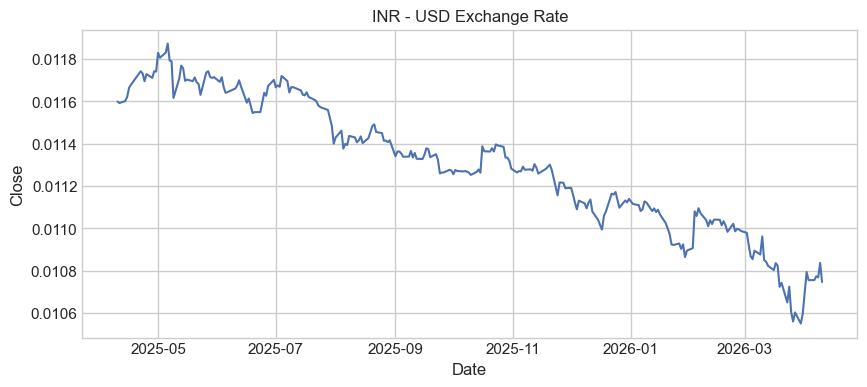

In [17]:
plt.figure(figsize=(10, 4))
plt.title("INR - USD Exchange Rate")
plt.xlabel("Date")
plt.ylabel("Close")
plt.plot(data["Close"])
plt.show()

Price               Close      High       Low      Open   Volume
Ticker           INRUSD=X  INRUSD=X  INRUSD=X  INRUSD=X INRUSD=X
Price  Ticker                                                   
Close  INRUSD=X  1.000000  0.932924  0.996471  0.999887      NaN
High   INRUSD=X  0.932924  1.000000  0.933148  0.932908      NaN
Low    INRUSD=X  0.996471  0.933148  1.000000  0.996451      NaN
Open   INRUSD=X  0.999887  0.932908  0.996451  1.000000      NaN
Volume INRUSD=X       NaN       NaN       NaN       NaN      NaN


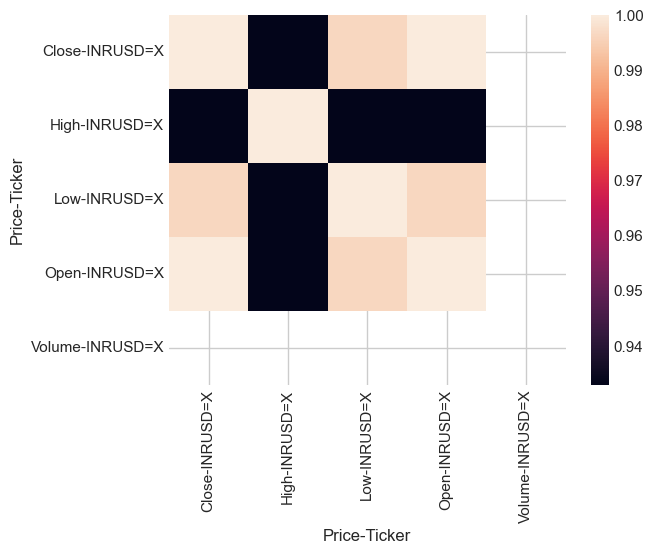

In [18]:
print(data.corr())
sns.heatmap(data.corr())
plt.show()

In [19]:
data

Price,Close,High,Low,Open,Volume
Ticker,INRUSD=X,INRUSD=X,INRUSD=X,INRUSD=X,INRUSD=X
Date,,,,,
2025-04-10,0.011600,0.011682,0.011583,0.011600,0
2025-04-11,0.011593,0.011636,0.011592,0.011593,0
2025-04-14,0.011602,0.011657,0.011601,0.011602,0
2025-04-15,0.011622,0.011683,0.011622,0.011622,0
2025-04-16,0.011665,0.011695,0.011660,0.011665,0
...,...,...,...,...,...
2026-04-06,0.010756,0.010811,0.010728,0.010756,0
2026-04-07,0.010774,0.010781,0.010736,0.010774,0


In [20]:
from prophet import Prophet
import pandas as pd

# yfinance'den gelen veriyi Prophet formatına sokalım
df_prophet = data.reset_index()[['Date', 'Close']]
df_prophet.columns = ['ds', 'y']

# Tarih sütunundaki saat bilgisini temizleyelim (sadece gün kalsın)
df_prophet['ds'] = df_prophet['ds'].dt.tz_localize(None)

In [22]:
# Modeli tanımla ve eğit
model = Prophet(daily_seasonality=True) # Döviz için günlük mevsimsellik açık kalsın
model.fit(df_prophet)

# Gelecek 30 gün için bir tarih çerçevesi oluştur
future = model.make_future_dataframe(periods=30)

# Tahmini gerçekleştir
forecast = model.predict(future)

# Sonuçları incele
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

23:06:54 - cmdstanpy - INFO - Chain [1] start processing
23:06:54 - cmdstanpy - INFO - Chain [1] done processing


            ds      yhat  yhat_lower  yhat_upper
283 2026-05-06  0.010577    0.010492    0.010668
284 2026-05-07  0.010573    0.010485    0.010667
285 2026-05-08  0.010562    0.010462    0.010656
286 2026-05-09  0.010555    0.010465    0.010656
287 2026-05-10  0.010550    0.010464    0.010646


## Summary
Predicting the currency exchange rates is the regression problem in machine learning. In this article, I used the Decision Tree Regression algorithm to predict the currency exchange rates. You can use other regression algorithms and even artificial neural networks for this task. I hope you liked this article on currency exchange rate prediction with machine learning using Python.